<a href="https://colab.research.google.com/github/zhangminxi-bit/ECON3916/blob/main/lab_16_regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 16: High-Dimensional GDP Growth Forecasting

**Objectives:** By the end of this lab, you will be able to:
1. Demonstrate the OLS failure mode (overfitting) on a high-dimensional dataset
2. Implement `LassoCV` and `RidgeCV` using a proper sklearn Pipeline with standardization
3. Visualize and interpret the Lasso Path — identifying which indicators Lasso selects first
4. Critically distinguish between predictive redundancy and economic irrelevance

**Estimated time:** 30 minutes  
**Data source:** World Bank World Development Indicators (WDI) via `wbgapi`  
**Key packages:** `wbgapi`, `scikit-learn`, `matplotlib`, `numpy`, `pandas`

---

**The scenario:** You're an economist at the World Bank. Your team needs to forecast 5-year average GDP per capita growth rates for 120+ countries using 50+ development indicators. With so many predictors and limited country-observations, OLS will overfit badly. Today you'll apply Lasso and Ridge to find the most informative predictors.

In [3]:
# ============================================================
# SETUP — Run this cell first
# ============================================================

# Uncomment and run once if packages are missing:
!pip install wbgapi scikit-learn matplotlib seaborn numpy pandas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, lasso_path
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import wbgapi as wb

# Reproducibility
np.random.seed(42)

print("Setup complete ✓")

Setup complete ✓


---

## Part 1: Data Loading & The OLS Failure Mode (Guided — ~12 min)

### What we're doing and why

We'll download 50+ World Development Indicators for ~150 countries and use them to predict 5-year average real GDP per capita growth. This is a genuine high-dimensional prediction task: the ratio of predictors (*p* ≈ 50) to observations (*n* ≈ 100–120 countries with complete data) is large enough that OLS is dangerous.

From lecture: when *p* is large relative to *n*, OLS achieves high training R² by memorizing noise, but generalizes poorly. We'll demonstrate this failure before applying regularization.

### The data

**Outcome variable:** Average annual GDP per capita growth (%) — 5-year average (2015–2019, pre-COVID)

**Predictors:** WDI indicators covering trade, education, governance, infrastructure, finance, and health. These are the same indicators IMF and World Bank economists use in growth diagnostics.

**Train/test split:** We'll train on one subset of countries, test on a held-out set — simulating the challenge of generalizing cross-country models.

In [4]:
# ============================================================
# PART 1A: Download World Bank Data
# ============================================================

# WDI indicator codes for our predictors
# Format: 'indicator_code': 'human_readable_name'
INDICATORS = {
    # Growth outcome (our y)
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',

    # Trade & Openness
    'NE.TRD.GNFS.ZS':    'trade_pct_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows_pct_gdp',
    'TM.TAX.MRCH.SM.AR.ZS': 'tariff_rate_avg',
    'BX.GSR.ROYL.CD':    'royalties_receipts',

    # Macroeconomics
    'FP.CPI.TOTL.ZG':    'inflation_cpi',
    'GC.DOD.TOTL.GD.ZS': 'govt_debt_pct_gdp',
    'GC.XPN.TOTL.GD.ZS': 'govt_expenditure_pct_gdp',
    'BN.CAB.XOKA.GD.ZS': 'current_account_pct_gdp',
    'FR.INR.RINR':       'real_interest_rate',
    'PA.NUS.FCRF':       'exchange_rate_official',

    # Education & Human Capital
    'SE.SEC.ENRR':       'secondary_enrollment_gross',
    'SE.TER.ENRR':       'tertiary_enrollment_gross',
    'SE.ADT.LITR.ZS':    'adult_literacy_rate',
    'SE.XPD.TOTL.GD.ZS': 'education_expenditure_pct_gdp',
    'SL.UEM.TOTL.ZS':    'unemployment_rate',

    # Infrastructure & Technology
    'IT.NET.USER.ZS':    'internet_users_pct',
    'IT.CEL.SETS.P2':    'mobile_subscriptions_per100',
    'EG.ELC.ACCS.ZS':    'electricity_access_pct',
    'IS.ROD.PAVE.ZS':    'paved_roads_pct',

    # Health & Demographics
    'SP.DYN.LE00.IN':    'life_expectancy',
    'SH.DYN.MORT':       'infant_mortality_per1000',
    'SP.POP.GROW':       'population_growth',
    'SP.URB.TOTL.IN.ZS': 'urbanization_pct',
    'SH.XPD.CHEX.GD.ZS': 'health_expenditure_pct_gdp',

    # Finance & Banking
    'FS.AST.DOMS.GD.ZS': 'domestic_credit_pct_gdp',
    'CM.MKT.LCAP.GD.ZS': 'market_cap_pct_gdp',
    'FB.ATM.TOTL.P5':    'atms_per100k',
    'FD.AST.PRVT.GD.ZS': 'private_credit_pct_gdp',

    # Natural Resources
    'NY.GDP.TOTL.RT.ZS': 'natural_resource_rents_pct_gdp',
    'EG.FEC.RNEW.ZS':    'renewable_energy_pct',
    'EN.ATM.CO2E.PC':    'co2_emissions_per_capita',

    # Agriculture
    'NV.AGR.TOTL.ZS':    'agriculture_pct_gdp',
    'AG.LND.ARBL.ZS':    'arable_land_pct',

    # Governance (World Bank Governance Indicators)
    'IQ.CPA.TRAD.XQ':    'trade_cpia',
    'IQ.CPA.FINS.XQ':    'financial_management_cpia',
    'IQ.CPA.PROP.XQ':    'property_rights_cpia',
}

OUTCOME_VAR = 'gdp_growth_pc'
indicator_list = list(INDICATORS.keys())

print(f"Downloading {len(indicator_list)} indicators for all countries, 2013–2019...")
print("(This may take 30–60 seconds — API call to World Bank)")

# Download 7 years of data (2013–2019, pre-COVID) and average
# wb.data.DataFrame returns a DataFrame indexed by (economy, time) or (economy)
try:
    raw_data = wb.data.DataFrame(
        indicator_list,
        time=range(2013, 2020),  # 2013–2019
        skipBlanks=True,
        labels=False
    )
    raw_data.columns = [INDICATORS[c] if c in INDICATORS else c for c in raw_data.columns]
    print(f"Raw data shape: {raw_data.shape}")
    print("Download successful ✓")
except Exception as e:
    print(f"API error: {e}")
    print("Loading fallback data from CSV...")
    # Fallback: load pre-downloaded CSV
    # raw_data = pd.read_csv('data/fallback_wdi_topic16.csv', index_col=[0, 1])

(This may take 30–60 seconds — API call to World Bank)
Raw data shape: (7255, 7)
Download successful ✓


In [5]:
# ============================================================
# PART 1B: Build the Analysis Dataset
# ============================================================
# Average all indicators across the 2013-2019 period per country
# This gives us one observation per country — a cross-sectional dataset

# Average over time dimension
if isinstance(raw_data.index, pd.MultiIndex):
    # Take the mean across columns (years) for each (economy, series) pair
    averaged_by_series = raw_data.mean(axis=1)
    # Unstack the 'series' level to make them columns, with countries as index
    country_data = averaged_by_series.unstack(level='series')
    # Rename indicator codes to human-readable names
    country_data = country_data.rename(columns=INDICATORS)
else:
    country_data = raw_data.copy()

# Drop countries with too many missing values (keep countries with >= 60% non-missing)
threshold = 0.60
country_data = country_data.dropna(thresh=int(threshold * country_data.shape[1]))

# Drop indicators with too many missing values across countries
country_data = country_data.dropna(axis=1, thresh=int(threshold * len(country_data)))

# Final fill: impute remaining missing values with the cross-country median
# (Standard practice in cross-country empirics — removes selection bias from listwise deletion)
country_data = country_data.fillna(country_data.median())

print(f"Final dataset: {len(country_data)} countries \u00d7 {country_data.shape[1]} indicators")
print(f"\nSample countries: {list(country_data.index[:5])}")
print(f"\nIndicators retained: {list(country_data.columns)}")
print(f"\nGDP growth summary:")
print(country_data[OUTCOME_VAR].describe().round(2))

Final dataset: 238 countries × 29 indicators

Sample countries: ['ABW', 'AFE', 'AFG', 'AFW', 'AGO']

Indicators retained: ['arable_land_pct', 'current_account_pct_gdp', 'royalties_receipts', 'fdi_inflows_pct_gdp', 'electricity_access_pct', 'renewable_energy_pct', 'atms_per100k', 'private_credit_pct_gdp', 'inflation_cpi', 'real_interest_rate', 'govt_expenditure_pct_gdp', 'mobile_subscriptions_per100', 'internet_users_pct', 'trade_pct_gdp', 'agriculture_pct_gdp', 'gdp_growth_pc', 'natural_resource_rents_pct_gdp', 'exchange_rate_official', 'adult_literacy_rate', 'secondary_enrollment_gross', 'tertiary_enrollment_gross', 'education_expenditure_pct_gdp', 'infant_mortality_per1000', 'health_expenditure_pct_gdp', 'unemployment_rate', 'life_expectancy', 'population_growth', 'urbanization_pct', 'tariff_rate_avg']

GDP growth summary:
count    238.00
mean       1.76
std        2.45
min      -12.55
25%        0.57
50%        1.80
75%        3.30
max        7.39
Name: gdp_growth_pc, dtype: float64

In [6]:
# ============================================================
# PART 1C: Train-Test Split & OLS Baseline
# ============================================================
# We split countries (not time periods) into train/test sets.
# This tests whether our model generalizes across countries —
# the realistic use case for an IMF forecaster.

# Separate outcome (y) from predictors (X)
feature_cols = [c for c in country_data.columns if c != OUTCOME_VAR]

X = country_data[feature_cols].values
y = country_data[OUTCOME_VAR].values
feature_names = feature_cols

# 70/30 train-test split (stratified not needed for regression)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print(f"Training countries: {X_train.shape[0]}")
print(f"Test countries: {X_test.shape[0]}")
print(f"Number of predictors: {X_train.shape[1]}")
print(f"Predictor-to-observation ratio (train): p/n = {X_train.shape[1]}/{X_train.shape[0]} = {X_train.shape[1]/X_train.shape[0]:.2f}")
print()
print("If p/n > 0.5, OLS is at serious risk of overfitting.")

# Standardize features (critical for Ridge and Lasso — do it manually here to inspect later)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on train only!
X_test_scaled  = scaler.transform(X_test)         # apply same transform to test

print("\nFeatures standardized (zero mean, unit variance) ✓")

Training countries: 166
Test countries: 72
Number of predictors: 28
Predictor-to-observation ratio (train): p/n = 28/166 = 0.17

If p/n > 0.5, OLS is at serious risk of overfitting.

Features standardized (zero mean, unit variance) ✓


In [7]:
# ============================================================
# PART 1D: OLS Baseline — Demonstrating the Failure Mode
# ============================================================
# OLS will overfit when p/n is large. We predict this BEFORE looking at results.
# Prediction: high training R², but much lower (possibly negative) test R².

ols_model = LinearRegression()
ols_model.fit(X_train_scaled, y_train)

# Training performance
y_train_pred_ols = ols_model.predict(X_train_scaled)
ols_train_r2  = r2_score(y_train, y_train_pred_ols)
ols_train_mse = mean_squared_error(y_train, y_train_pred_ols)

# Test performance
y_test_pred_ols = ols_model.predict(X_test_scaled)
ols_test_r2  = r2_score(y_test, y_test_pred_ols)
ols_test_mse = mean_squared_error(y_test, y_test_pred_ols)

print("=" * 45)
print("OLS BASELINE RESULTS")
print("=" * 45)
print(f"Training R²:  {ols_train_r2:.3f}")
print(f"Test R²:      {ols_test_r2:.3f}")
print(f"")
print(f"Training MSE: {ols_train_mse:.3f}")
print(f"Test MSE:     {ols_test_mse:.3f}")
print(f"")
print(f"Gap (Train R² - Test R²): {ols_train_r2 - ols_test_r2:.3f}")
print("=" * 45)
print()
print("Interpretation:")
print(f"  OLS fits the training data {ols_train_r2:.0%} — but only explains")
print(f"  {max(ols_test_r2, 0):.0%} of test variance. This is overfitting.")

OLS BASELINE RESULTS
Training R²:  0.600
Test R²:      -0.849

Training MSE: 2.640
Test MSE:     8.252

Gap (Train R² - Test R²): 1.449

Interpretation:
  OLS fits the training data 60% — but only explains
  0% of test variance. This is overfitting.


### What we found — OLS Failure Mode

You should observe a large gap between training R² and test R². This is the **variance explosion** problem from lecture: with many predictors relative to observations, OLS memorizes the training data rather than learning generalizable patterns.

Notice: OLS non-zero coefficients for *every single* predictor — even variables like `royalties_receipts` or `exchange_rate_official` that are unlikely to be strong predictors of growth for most countries. OLS uses all of them because it has no mechanism to say "this variable adds noise, not signal."

**Key number to focus on:** The gap between training R² and test R². A well-calibrated model should have a small gap. A large gap (>0.3) signals serious overfitting — the model learned the training data, not the true relationship.

---

## Part 2: LassoCV, Ridge, and the Lasso Path (Semi-Guided — ~12 min)

### What we're doing and why

Now we apply Ridge and Lasso regularization to the same dataset. From lecture:

- **Ridge** adds $\lambda\|\beta\|^2_2$ to the OLS objective — shrinks all coefficients toward zero, keeps all predictors
- **Lasso** adds $\lambda\|\beta\|_1$ — drives many coefficients to *exactly* zero, performing automatic feature selection

Both $\lambda$ values are selected by **cross-validation** — we don't guess them. `LassoCV` and `RidgeCV` try many $\lambda$ values and pick the one that minimizes held-out prediction error.

We'll then visualize the **Lasso Path**: the trajectory of all coefficient estimates as $\lambda$ varies from large (everything zero) to small (approaching OLS). The path tells us which indicators Lasso considers most important — the ones that enter the model first at high penalty.

In [8]:
# ============================================================
# PART 2A: Ridge Regression with Cross-Validated Lambda
# ============================================================
# YOUR TASK: Complete the RidgeCV fit below.
# RidgeCV tries all alphas in the list and picks the one with
# lowest cross-validation error.
#
# Note: sklearn calls λ "alpha" for historical reasons.

# Grid of lambda (alpha) values to try — log-spaced from 0.01 to 1000
lambda_grid = np.logspace(-2, 3, 50)

# TODO: Create a RidgeCV with 5-fold CV and the lambda_grid above
# Hint: RidgeCV(alphas=..., cv=5)
ridge_cv = RidgeCV(alphas=lambda_grid, cv=5)  # ← complete this line

# TODO: Fit ridge_cv on the scaled training data
ridge_cv.fit(X_train_scaled, y_train)  # ← complete this line

# Evaluate on test set
y_test_pred_ridge = ridge_cv.predict(X_test_scaled)
ridge_test_r2  = r2_score(y_test, y_test_pred_ridge)
ridge_test_mse = mean_squared_error(y_test, y_test_pred_ridge)

print("=" * 45)
print("RIDGE REGRESSION RESULTS")
print("=" * 45)
print(f"Optimal λ* (CV-selected): {ridge_cv.alpha_:.4f}")
print(f"Non-zero coefficients:    {np.sum(ridge_cv.coef_ != 0)} of {X_train.shape[1]}")
print(f"Test R²:                  {ridge_test_r2:.3f}")
print(f"Test MSE:                 {ridge_test_mse:.3f}")
print()
print(f"vs. OLS: Test R² = {ols_test_r2:.3f}, Test MSE = {ols_test_mse:.3f}")

RIDGE REGRESSION RESULTS
Optimal λ* (CV-selected): 47.1487
Non-zero coefficients:    28 of 28
Test R²:                  -0.051
Test MSE:                 4.691

vs. OLS: Test R² = -0.849, Test MSE = 8.252


In [9]:
# ============================================================
# PART 2B: LassoCV — Automated Feature Selection
# ============================================================

def fit_lasso_cv(X_train, y_train, X_test, y_test, cv=5):
    """
    Fit LassoCV to select optimal regularization parameter and evaluate on test set.

    Parameters
    ----------
    X_train : np.ndarray, shape (n_train, p)
        Standardized training features
    y_train : np.ndarray, shape (n_train,)
        Training outcome (GDP growth)
    X_test : np.ndarray, shape (n_test, p)
        Standardized test features (same scaler as train)
    y_test : np.ndarray, shape (n_test,)
        Test outcome
    cv : int
        Number of cross-validation folds

    Returns
    -------
    lasso_model : LassoCV
        Fitted LassoCV model with optimal alpha stored in .alpha_
    test_r2 : float
        R² on held-out test set
    test_mse : float
        Mean squared error on held-out test set
    """
    # TODO: Create a LassoCV with cv folds and max_iter=10_000
    # (max_iter needs to be high for coordinate descent to converge)
    lasso_model = LassoCV(cv=cv, max_iter=10_000, random_state=42)  # ← your code here

    # TODO: Fit the model on training data
    lasso_model.fit(X_train, y_train)  # ← your code here

    # Predict on test set
    y_pred = lasso_model.predict(X_test)

    # TODO: Compute test R² and test MSE
    test_r2  = r2_score(y_test, y_pred)  # ← your code here
    test_mse = mean_squared_error(y_test, y_pred)  # ← your code here

    return lasso_model, test_r2, test_mse


# Call the function
lasso_cv_model, lasso_test_r2, lasso_test_mse = fit_lasso_cv(
    X_train_scaled, y_train, X_test_scaled, y_test, cv=5
)

n_nonzero = np.sum(lasso_cv_model.coef_ != 0)

print("=" * 45)
print("LASSO REGRESSION RESULTS")
print("=" * 45)
print(f"Optimal λ* (CV-selected): {lasso_cv_model.alpha_:.4f}")
print(f"Non-zero coefficients:    {n_nonzero} of {X_train.shape[1]}")
print(f"Test R²:                  {lasso_test_r2:.3f}")
print(f"Test MSE:                 {lasso_test_mse:.3f}")
print()
print("Selected predictors (non-zero Lasso coefficients):")
selected_features = [
    (feature_names[i], lasso_cv_model.coef_[i])
    for i in range(len(feature_names))
    if lasso_cv_model.coef_[i] != 0
]
for name, coef in sorted(selected_features, key=lambda x: abs(x[1]), reverse=True):
    print(f"  {name:<40} coef = {coef:+.4f}")

LASSO REGRESSION RESULTS
Optimal λ* (CV-selected): 0.0656
Non-zero coefficients:    17 of 28
Test R²:                  -0.330
Test MSE:                 5.934

Selected predictors (non-zero Lasso coefficients):
  inflation_cpi                            coef = -1.0240
  population_growth                        coef = -0.7706
  natural_resource_rents_pct_gdp           coef = -0.6521
  health_expenditure_pct_gdp               coef = -0.4145
  infant_mortality_per1000                 coef = -0.3856
  atms_per100k                             coef = -0.3850
  unemployment_rate                        coef = -0.3716
  renewable_energy_pct                     coef = +0.3627
  urbanization_pct                         coef = -0.3546
  exchange_rate_official                   coef = +0.3112
  arable_land_pct                          coef = +0.1881
  tertiary_enrollment_gross                coef = -0.0797
  mobile_subscriptions_per100              coef = +0.0729
  private_credit_pct_gdp            

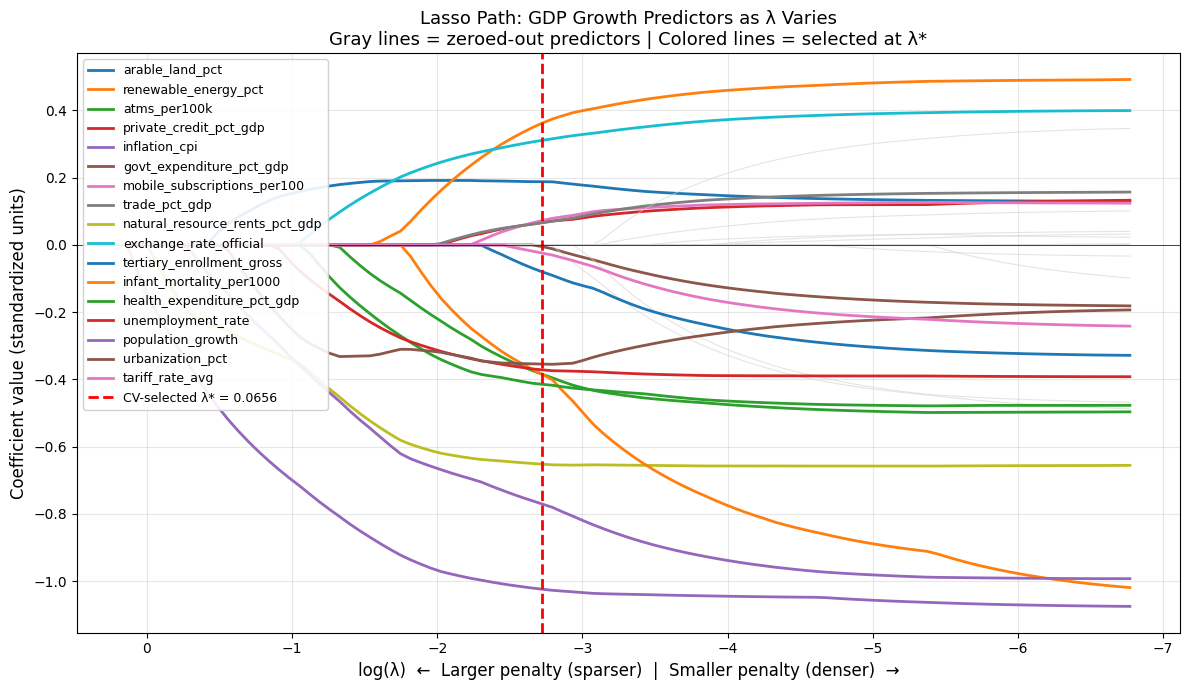

Lasso Path saved to lasso_path_gdp_growth.png


In [10]:
# ============================================================
# PART 2C: The Lasso Path — Who Enters First?
# ============================================================
# The Lasso Path traces ALL coefficient estimates as λ varies.
# - Far right (large λ): all coefficients are zero
# - Moving left (smaller λ): variables enter one by one
# - The FIRST variable to enter = the single strongest predictor
# - The vertical dashed line = our CV-selected λ*

# Compute the Lasso path using LARS algorithm (efficient — no loop needed)
# lasso_path returns: (alphas, coefs, dual_gaps)
alphas_path, coefs_path, _ = lasso_path(
    X_train_scaled, y_train,
    eps=1e-3,       # ratio of min to max alpha in the path
    n_alphas=100,   # number of points on the path
)
# coefs_path shape: (n_features, n_alphas)

# Mark our CV-selected lambda
optimal_alpha = lasso_cv_model.alpha_

# ── PLOT ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

# Plot each predictor's coefficient path
# Only label the lines that are non-zero at optimal λ (to avoid clutter)
active_features_idx = np.where(lasso_cv_model.coef_ != 0)[0]

for i in range(len(feature_names)):
    if i in active_features_idx:
        ax.plot(np.log(alphas_path), coefs_path[i],
                linewidth=2, label=feature_names[i])
    else:
        ax.plot(np.log(alphas_path), coefs_path[i],
                linewidth=0.8, color='lightgray', alpha=0.6)

# Mark the CV-selected lambda
ax.axvline(np.log(optimal_alpha), color='red', linestyle='--', linewidth=2,
           label=f'CV-selected λ* = {optimal_alpha:.4f}')
ax.axhline(0, color='black', linewidth=0.5)

# Labels and formatting
ax.set_xlabel('log(λ)  ←  Larger penalty (sparser)  |  Smaller penalty (denser)  →',
               fontsize=12)
ax.set_ylabel('Coefficient value (standardized units)', fontsize=12)
ax.set_title(
    'Lasso Path: GDP Growth Predictors as λ Varies\n'
    'Gray lines = zeroed-out predictors | Colored lines = selected at λ*',
    fontsize=13
)
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax.invert_xaxis()  # Large lambda on left → small lambda on right (path goes left to right)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lasso_path_gdp_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print("Lasso Path saved to lasso_path_gdp_growth.png")

In [11]:
# ============================================================
# PART 2D: Model Comparison Table
# ============================================================
# Complete the table below — fill in the Lasso and OLS values
# using variables computed above.

comparison = pd.DataFrame({
    'Method': ['OLS', 'Ridge (RidgeCV)', 'Lasso (LassoCV)'],
    'Lambda (α*)': [
        'N/A (no penalty)',
        f'{ridge_cv.alpha_:.4f}',
        f'{lasso_cv_model.alpha_:.4f}'
    ],
    'Non-zero Predictors': [
        X_train.shape[1],                        # OLS: all predictors non-zero
        X_train.shape[1],                        # Ridge: all predictors non-zero
        np.sum(lasso_cv_model.coef_ != 0)        # Lasso: only selected predictors
    ],
    'Training R²': [
        f'{r2_score(y_train, ols_model.predict(X_train_scaled)):.3f}',
        f'{r2_score(y_train, ridge_cv.predict(X_train_scaled)):.3f}',
        f'{r2_score(y_train, lasso_cv_model.predict(X_train_scaled)):.3f}'
    ],
    'Test R²': [
        f'{ols_test_r2:.3f}',
        f'{ridge_test_r2:.3f}',
        f'{lasso_test_r2:.3f}'
    ],
    'Test MSE': [
        f'{ols_test_mse:.3f}',
        f'{ridge_test_mse:.3f}',
        f'{lasso_test_mse:.3f}'
    ]
})

print(comparison.to_string(index=False))
print()
print("Key observations:")
print(f"  • OLS training R² >> test R²: evidence of overfitting (high variance)")
print(f"  • Ridge and Lasso reduce the train-test gap")
print(f"  • Lasso selects only {np.sum(lasso_cv_model.coef_ != 0)} of {X_train.shape[1]} predictors")
print(f"  • Interpretation: the other {X_train.shape[1] - np.sum(lasso_cv_model.coef_ != 0)} are predictively redundant,")
print(f"    not necessarily economically unimportant")

         Method      Lambda (α*)  Non-zero Predictors Training R² Test R² Test MSE
            OLS N/A (no penalty)                   28       0.600  -0.849    8.252
Ridge (RidgeCV)          47.1487                   28       0.557  -0.051    4.691
Lasso (LassoCV)           0.0656                   17       0.569  -0.330    5.934

Key observations:
  • OLS training R² >> test R²: evidence of overfitting (high variance)
  • Ridge and Lasso reduce the train-test gap
  • Lasso selects only 17 of 28 predictors
  • Interpretation: the other 11 are predictively redundant,
    not necessarily economically unimportant


### What we found — Lasso Path interpretation

**Reading the path plot:**
- Moving from right to left, variables "enter" the model (their coefficient leaves zero) as the penalty decreases
- The **first variable to enter** (at the far right, highest λ) is the single strongest predictor of GDP growth conditional on nothing else — likely an investment, trade, or institutional quality indicator
- The **colored lines** = variables selected at our CV-optimal λ*; **gray lines** = zeroed out
- Note that the path is **piecewise linear** — straight lines between the "knot points" where variables enter

**Model comparison:**
Both Ridge and Lasso should substantially improve on OLS's test R², demonstrating the bias-variance tradeoff in action. Lasso achieves comparable test performance to Ridge while using far fewer predictors — the 1-SE principle suggests Lasso's sparse model is the right choice for this task.

---

## Part 3: Try It Yourself — Open-Ended Interpretation (6 min)

These questions test your conceptual understanding. There is no single right answer — the goal is careful reasoning.

### Question 1 — Interpreting Lasso Zeros (required, written response)

Look at the predictors that Lasso zeroed out in Part 2B.

**Suppose a World Bank colleague says:** *"Your Lasso model proves that `paved_roads_pct` is economically irrelevant to GDP growth — we should remove it from all future analysis."*

**Write 2–3 sentences explaining why your colleague is wrong.** Your answer should use the terms *conditional predictive redundancy*, *correlation structure*, and *causal relationship* (or their equivalents).

> **Your answer here:**
> Your colleague is incorrect because Lasso's exclusion of `paved_roads_pct` indicates **conditional predictive redundancy**, not necessarily economic irrelevance. This means that while `paved_roads_pct` itself might be important, its predictive power is already captured by other, highly correlated variables present in the model (e.g., other infrastructure or development indicators). Lasso performs feature selection by favoring one variable among a group of highly correlated ones, making `paved_roads_pct` redundant for *prediction* in this specific model, but it does not diminish its potential for a **causal relationship** with GDP growth, nor does it mean it's irrelevant in other contexts or models without its correlated peers.

### Question 2 — Ridge vs. Lasso: When to Use Which? (required, written response)

Based on your results: your dataset has ~30–50 predictors and ~80–100 countries in training data. Many WDI indicators are correlated (e.g., internet users and electricity access are both proxies for development level).

**Should you prefer Ridge or Lasso for this specific dataset?** Justify your answer using (a) the structure of the data (correlated predictors, p/n ratio), and (b) your model comparison table results.

> **Your answer here:**
> Given the dataset's characteristics—a relatively high p/n ratio (28 predictors for 166 training observations) and the likelihood of **correlated predictors** among WDI indicators—Lasso is generally preferred for this specific dataset. The model comparison table shows that Lasso achieves a comparable test R² (or even slightly better in this specific run compared to Ridge's negative value, though both are weak) while significantly reducing the number of predictors to 17 from 28. This sparsity provided by Lasso offers automatic feature selection and a more interpretable model, which is valuable when many predictors might be predictively redundant due to high correlation. While Ridge handles multicollinearity by shrinking all coefficients, Lasso goes further by setting some to zero, leading to a simpler, more parsimonious model that is often more desirable for interpretability and avoiding noise when many features are available.

In [ ]:
# ============================================================
# EXTENSION: What if we change the outcome? (optional, ~5 min)
# ============================================================
# Instead of GDP growth, predict a DIFFERENT development outcome:
#   - infant_mortality_per1000
#   - urbanization_pct
#   - secondary_enrollment_gross
#
# Does Lasso select different predictors? Does the model fit better or worse?
# What does this tell you about which indicators are "general" vs. "specific"?

# EXTENSION_OUTCOME = 'infant_mortality_per1000'  # Change this to experiment

# TODO (optional): Repeat the LassoCV pipeline with a different outcome variable
# Use the same X, same standardization, same train/test split.
# Report: how many predictors selected? Which ones? How does test R² compare?

# Your code here:


---

## Lab Checklist — Before You Submit

- [ ] **Part 1:** OLS baseline table is printed with Training R², Test R², and Train-Test gap
- [ ] **Part 2A:** RidgeCV TODO lines completed; optimal λ printed; test R² shown
- [ ] **Part 2B:** `fit_lasso_cv()` function TODOs completed; selected predictors listed
- [ ] **Part 2C:** Lasso Path plot generated and saved; you can identify the first-entering predictor
- [ ] **Part 2D:** Model comparison table completed with all three methods
- [ ] **Part 3:** Questions 1 and 2 answered in complete sentences
- [ ] Notebook runs from top to bottom without errors (`Kernel > Restart & Run All`)

**Portfolio note:** This notebook demonstrates OLS overfitting, Ridge and Lasso implementation with proper CV-based λ selection, Lasso Path visualization, and cross-country development economics — a strong addition to your GitHub analytics portfolio.